# dring quick start figures

This notebook starts from a YAML config, plots the input intensity profiles with uncertainty bands and selected fitting radii, then shows the commands used to enter the Bayesian fitting stage.

Default example: `configs/HD163296_ring1.yaml`. Change `CONFIG_PATH` in the first code cell to inspect another target or ring.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from dring import load_config
from ringfit.fitter import RingFitProblem

# Select one YAML config. Paths inside the config are resolved relative to the project root.
CONFIG_PATH = Path("configs/HD163296_ring1.yaml")

config = load_config(CONFIG_PATH)
problem = RingFitProblem(config)

print(f"config: {CONFIG_PATH}")
print(f"output_dir: {config.get('output_dir')}")
print(f"scattering_formula: {problem.scattering_formula}")
print(f"bands: {problem.band_names}")
print(f"fit radii [au]: {[r.tolist() for r in problem.fit_radii]}")
print(f"parameters: {problem.parameters}")


config: configs/HD163296_ring1.yaml
output_dir: /media/lhyang/SHAO_HPC/project_papper2/dring_rad/results/HD163296_ring1
scattering_formula: zhu2019
bands: ['band7', 'band6', 'band3']
fit radii [au]: [[64.0, 67.0, 71.0], [64.0, 67.0, 71.0], [64.0, 67.0, 71.0]]
parameters: ['alpha', 'vf', 'eps', 'T', 'c_lam1', 'c_lam2', 'c_lam3']


## Input intensity profiles

The shaded region shows `intensity +/- rms_error`. The vertical dotted lines mark the radii selected by the YAML config for the likelihood. No best-fit model is overlaid in this first quick-look figure.


PosixPath('figures_input_intensity_profile.png')

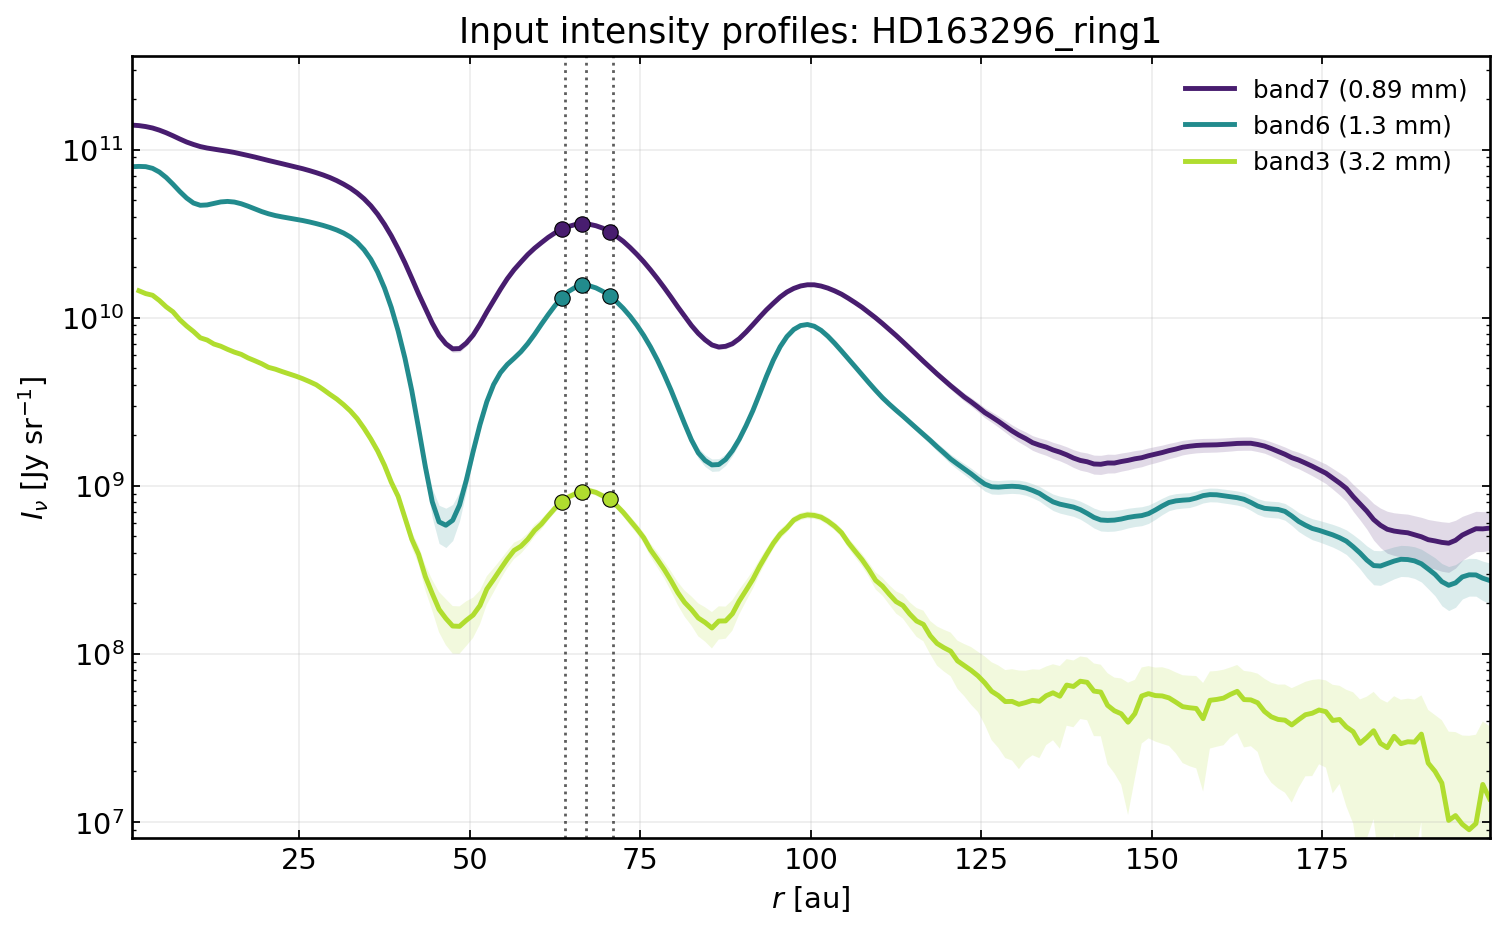

In [2]:
plt.rcParams.update({
    "font.size": 13,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

colors = plt.cm.viridis(np.linspace(0.08, 0.88, problem.n_band))
fig, ax = plt.subplots(figsize=(9.6, 6.0), dpi=160)

positive_fit_values = []
all_radii = []
for iband, color in enumerate(colors):
    radius = np.asarray(problem.radius_au[iband], dtype=float)
    intensity = np.asarray(problem.obs_intensity[iband], dtype=float)
    rms = np.asarray(problem.obs_rms[iband], dtype=float)
    finite = np.isfinite(radius) & np.isfinite(intensity) & np.isfinite(rms)
    positive = finite & (intensity > 0)
    all_radii.append(radius[finite])

    if np.any(positive):
        y_floor = np.nanmin(intensity[positive]) * 1e-3
    else:
        y_floor = 1e-99
    y_low = np.maximum(intensity - rms, y_floor)
    y_high = intensity + rms
    fill_mask = finite & (y_high > 0)

    label = f"{problem.band_names[iband]} ({problem.wavelengths[iband] * 10.0:.3g} mm)"
    ax.plot(radius[finite], intensity[finite], color=color, lw=2.2, label=label)
    ax.fill_between(radius[fill_mask], y_low[fill_mask], y_high[fill_mask], color=color, alpha=0.16, lw=0)

    fit_idx = np.asarray(problem.fit_indices[iband], dtype=int)
    ax.scatter(radius[fit_idx], intensity[fit_idx], color=color, s=48, edgecolor="k", linewidth=0.5, zorder=5)
    fit_values = intensity[fit_idx]
    fit_positive = np.isfinite(fit_values) & (fit_values > 0)
    if np.any(fit_positive):
        positive_fit_values.append(fit_values[fit_positive])

# Draw unique fitting radii. For the simple first-version configs these are usually three vertical lines.
unique_fit_radii = np.unique(np.round(np.concatenate([np.asarray(r, dtype=float) for r in problem.fit_radii]), 8))
for radius in unique_fit_radii:
    ax.axvline(radius, color="0.25", ls=":", lw=1.25, alpha=0.85)

ax.set_yscale("log")
ax.set_xlabel(r"$r$ [au]")
ax.set_ylabel(r"$I_\nu$ [Jy sr$^{-1}$]")
ax.set_title(f"Input intensity profiles: {CONFIG_PATH.stem}")
ax.legend(frameon=False, fontsize=11)
ax.grid(alpha=0.22)

if all_radii:
    stacked_r = np.concatenate(all_radii)
    ax.set_xlim(np.nanmin(stacked_r), np.nanmax(stacked_r))
if positive_fit_values:
    stacked_y = np.concatenate(positive_fit_values)
    ax.set_ylim(np.nanmin(stacked_y) / 100.0, np.nanmax(stacked_y) * 10.0)

fig.tight_layout()
output = Path("figures_input_intensity_profile.png")
fig.savefig(output, dpi=180, bbox_inches="tight")
output


## Bayesian fitting stage

The YAML config now contains the data paths, opacity table, model setup, priors, sampler options, output directory, and analysis products. Start with a config check, then launch the fit.


In [3]:
print("Check the config without starting UltraNest:")
print(f"dring fit -c {CONFIG_PATH} --check-config")
print()
print("Run a single-process fit:")
print(f"dring fit -c {CONFIG_PATH}")
print()
print("Run an MPI fit on a cluster:")
print(f"mpiexec -n 30 python -m dring fit -c {CONFIG_PATH}")


Check the config without starting UltraNest:
dring fit -c configs/HD163296_ring1.yaml --check-config

Run a single-process fit:
dring fit -c configs/HD163296_ring1.yaml

Run an MPI fit on a cluster:
mpiexec -n 30 python -m dring fit -c configs/HD163296_ring1.yaml


In [4]:
# Optional in-notebook config check. This does not run UltraNest.
cube = np.full(len(problem.parameters), 0.5)
theta = problem.prior_transform(cube)
model_r_au, model_profiles = problem.model_profiles(theta)

print("Configuration OK")
print("sample parameter vector from prior midpoint:")
for name, value in zip(problem.parameters, theta):
    print(f"  {name:>8s} = {value:.6g}")
print(f"model grid: {model_r_au[0]:.2f} - {model_r_au[-1]:.2f} au, n={model_r_au.size}")
print(f"profile array shape: {model_profiles.shape}")


Configuration OK
sample parameter vector from prior midpoint:
     alpha = 0.000316228
        vf = 100
       eps = 0.0316228
         T = 17.5
    c_lam1 = 1
    c_lam2 = 1
    c_lam3 = 1
model grid: 24.38 - 110.62 au, n=101
profile array shape: (3, 101)


## After the fit

Once the result directory exists, the same config controls the post-fit products.


In [5]:
result_dir = Path(config["output_dir"])
print(f"dring plot -r {result_dir}")
print(f"dring derived -r {result_dir}")
print(f"dring intensity -r {result_dir}")


dring plot -r /media/lhyang/SHAO_HPC/project_papper2/dring_rad/results/HD163296_ring1
dring derived -r /media/lhyang/SHAO_HPC/project_papper2/dring_rad/results/HD163296_ring1
dring intensity -r /media/lhyang/SHAO_HPC/project_papper2/dring_rad/results/HD163296_ring1


## Python API: build a dust-ring model

The lower-level API can be used without starting a Bayesian fit. Here we manually construct a `DustRingModel` from the same physical setup as the YAML config, then inspect the reconstructed dust surface-density distribution.


In [6]:
import dring

model_cfg = config["model"]
manual_model = dring.make_model(
    alpha=1e-3,
    vf=100.0,
    sigma_g=model_cfg["sigma_g"],
    eps=3e-2,
    pressure_width_au=model_cfg["pressure_width_au"],
    temperature=20.0,
    ring_center_au=model_cfg["ring_center_au"],
    stellar_mass_msun=model_cfg["stellar_mass_msun"],
    r_grid_au=np.linspace(
        model_cfg["ring_center_au"] - 4.0 * model_cfg["pressure_width_au"],
        model_cfg["ring_center_au"] + 4.0 * model_cfg["pressure_width_au"],
        260,
    ),
    a_min=model_cfg.get("a_min", 1e-5),
    a_max=model_cfg.get("a_max", 100.0),
    rho_s=problem.opacity["rho_s"],
    size_res=model_cfg.get("size_res", 100),
    temperature_slope=model_cfg.get("temperature_slope", -0.5),
    size_distribution_q=model_cfg.get("size_distribution_q", -3.5),
)

print("model products")
print("  r_grid [au]:", manual_model.r_grid[0] / 1.495978707e13, "to", manual_model.r_grid[-1] / 1.495978707e13)
print("  size grid [cm]:", manual_model.size[0], "to", manual_model.size[-1])
print("  SigmaDust shape:", manual_model.SigmaDust.shape)
print("  T range [K]:", np.nanmin(manual_model.T), np.nanmax(manual_model.T))


model products
  r_grid [au]: 9.399999999999999 to 124.6
  size grid [cm]: 1e-05 to 100.0
  SigmaDust shape: (260, 100)
  T range [K]: 14.665888398048475 53.395354009382075


## Plot the reconstructed dust surface-density distribution

`SDplot()` is a convenience method attached to every `DustRingModel`. It plots `log10(SigmaDust / dlnm)` on the model radial and grain-size grids.


PosixPath('figures_sigma_dust.png')

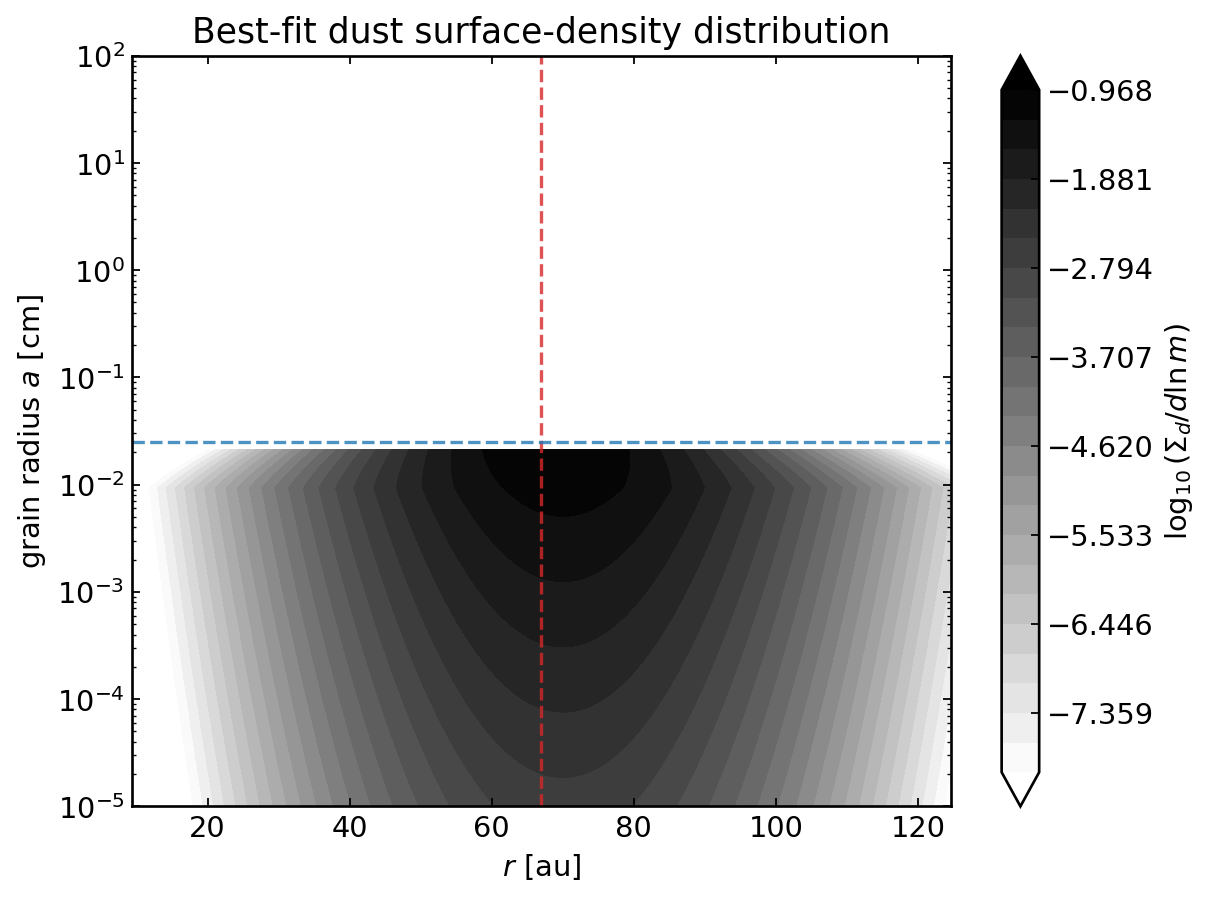

In [7]:
sigma_output = Path("figures_sigma_dust.png")
fig_sd, ax_sd = manual_model.SDplot(output=sigma_output, close=False)
sigma_output


## Three-band radiative transfer from the manual model

Now use the config opacity table and the three observed wavelengths to compute raw, unconvolved intensity profiles. This calls the same radiative-transfer interface used by the fitting code, but without Bayesian sampling.


In [8]:
opacity_inputs = dict(config["opacity"])
wavelengths_cm = problem.wavelengths

r_model_au, raw_profiles = dring.compute_profile(
    model=manual_model,
    wavelengths_cm=wavelengths_cm,
    opacity=opacity_inputs,
    inclination_deg=config["inclination_deg"],
    scattering_formula=config.get("scattering_formula", "zhu2019"),
)

print("r_model_au shape:", r_model_au.shape)
print("raw_profiles shape:", raw_profiles.shape)
print("scattering_formula:", config.get("scattering_formula", "zhu2019"))


r_model_au shape: (260,)
raw_profiles shape: (3, 260)
scattering_formula: zhu2019


PosixPath('figures_manual_model_three_band_rt.png')

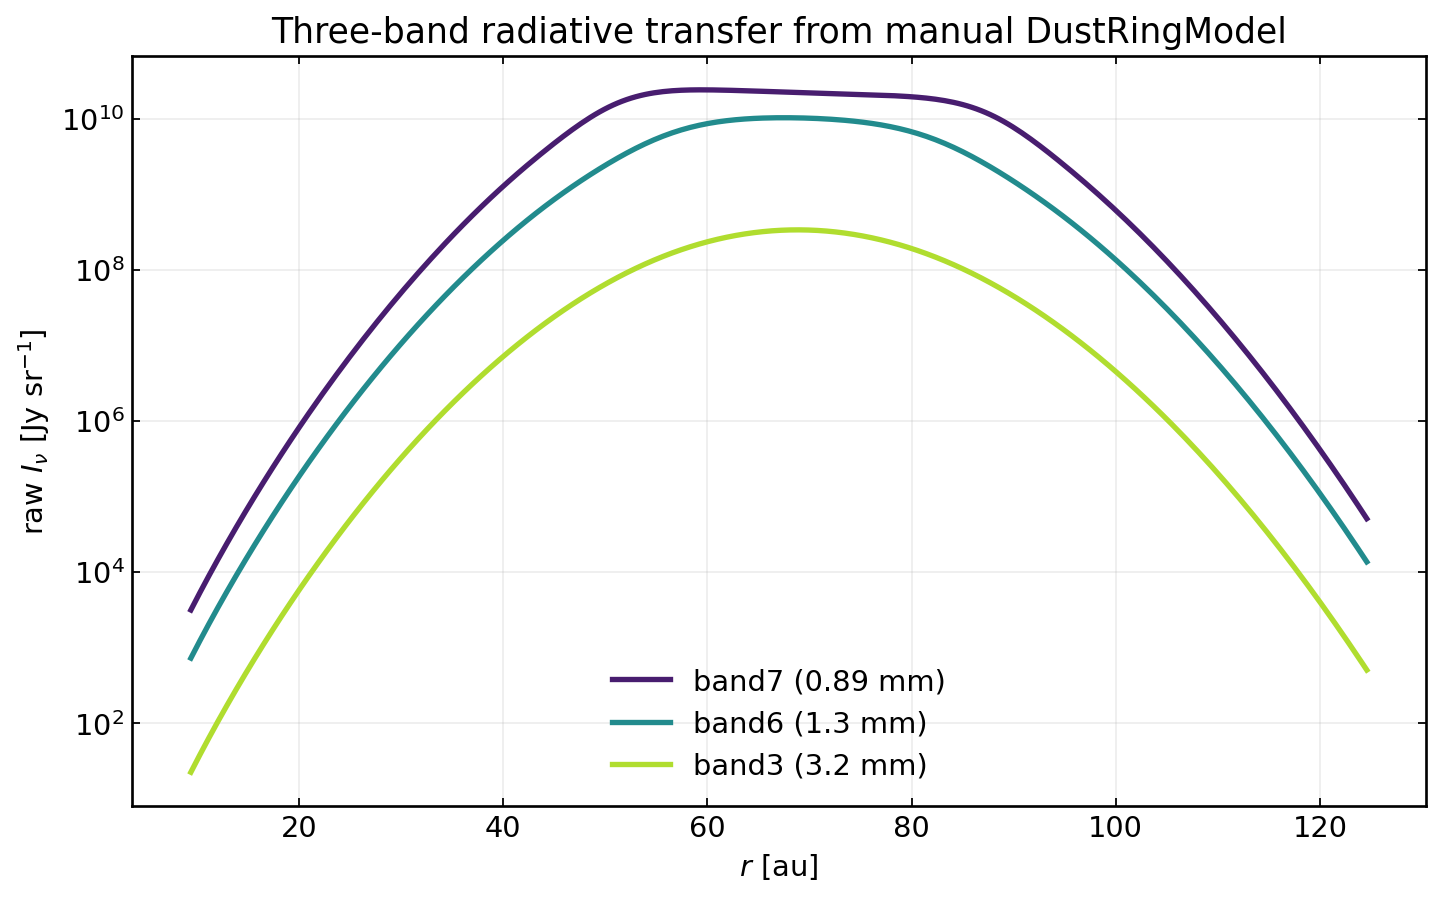

In [9]:
fig, ax = plt.subplots(figsize=(9.2, 5.8), dpi=160)
colors = plt.cm.viridis(np.linspace(0.08, 0.88, len(wavelengths_cm)))

for iband, color in enumerate(colors):
    label = f"{problem.band_names[iband]} ({wavelengths_cm[iband] * 10.0:.3g} mm)"
    ax.plot(r_model_au, raw_profiles[iband], color=color, lw=2.4, label=label)

ax.set_yscale("log")
ax.set_xlabel(r"$r$ [au]")
ax.set_ylabel(r"raw $I_\nu$ [Jy sr$^{-1}$]")
ax.set_title("Three-band radiative transfer from manual DustRingModel")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
fig.tight_layout()
rt_output = Path("figures_manual_model_three_band_rt.png")
fig.savefig(rt_output, dpi=180, bbox_inches="tight")
rt_output
